# Trial Quality: Distinguishing True Decisions from Guessing

## Motivation

The bound-inference algorithm assumes that every trial reflects a genuine decision: the
subject accumulates evidence until the decision variable crosses a bound, then responds
with a random NDT delay. Under this model, the sign of the inferred bound should reliably
predict the choice direction — i.e., congruence ≈ 1.

But for very short RTs (typically corresponding to very low bounds), subjects may instead
be guessing or responding inattentively, without waiting for evidence to accumulate. For
these trials, the bound estimate is computed from a random walk that has no reliable
relationship to the choice, so congruence ≈ 0.5 (chance).

This is important because:
1. The bias correction notebook assumes all trials follow the generative model — including
   those with very small bounds. If low-bound trials are mostly guesses, the correction
   is miscalibrated for that regime.
2. Including guess trials in bound analyses inflates the apparent prevalence of low bounds
   and distorts the bound distribution.

## Approach

Compute **per-trial congruence** — whether `sign(bound)` matches the choice direction —
and examine how it varies with RT across subjects. A sharp drop toward chance (0.5) at
low RT would indicate a regime dominated by guessing and suggest a minimum RT cutoff.

**Key question**: Is there a natural RT threshold below which congruence is at or near
chance, and above which it reliably exceeds chance? If so, that threshold can serve as
an inclusion criterion for bound analyses.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

from pigeon.data import get_data_table

TASK_TYPE = 'OL'   # start with Open-Loop data
MIN_TRIALS_PER_BIN = 10   # minimum trials in an RT bin to plot/include

print(f'Loading {TASK_TYPE} data...')
df = get_data_table(task_type=TASK_TYPE, correct_bias=None)
print(f'Loaded {len(df):,} trials from {df.subject_index.nunique()} subjects')
print(f'Columns: {list(df.columns)}')
print(f'RT range: {df.RT.min():.0f} – {df.RT.max():.0f}  (median {df.RT.median():.1f})')
print(f'SNR values: {sorted(df.snr.unique())}')

Loading OL data...
  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/

In [3]:
# Per-trial congruence: 1 if sign(bound) matches choice direction, 0 otherwise.
# bound is NaN for very short trials (RT < 2) and wall-hits; those are excluded.
choice_pm = df.choice * 2 - 1            # 0/1 → -1/+1
df = df.copy()
df['congruent'] = (
    np.sign(df.bound) == np.sign(choice_pm)
).astype(float)
df.loc[~np.isfinite(df.bound), 'congruent'] = np.nan   # NaN bound → NaN congruence

print(f'Trials with valid bound:  {np.isfinite(df.bound).sum():,} / {len(df):,}')
print(f'Overall mean congruence:  {df.congruent.mean():.3f}')

Trials with valid bound:  15,977 / 15,977
Overall mean congruence:  0.759


/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_31384/3473309926.py:20: RuntimeWarning: Mean of empty slice
  mean_cong = np.nanmean(cong_matrix, axis=0)
/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_31384/3473309926.py:21: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_cong  = stats.sem(cong_matrix, axis=0, nan_policy='omit')


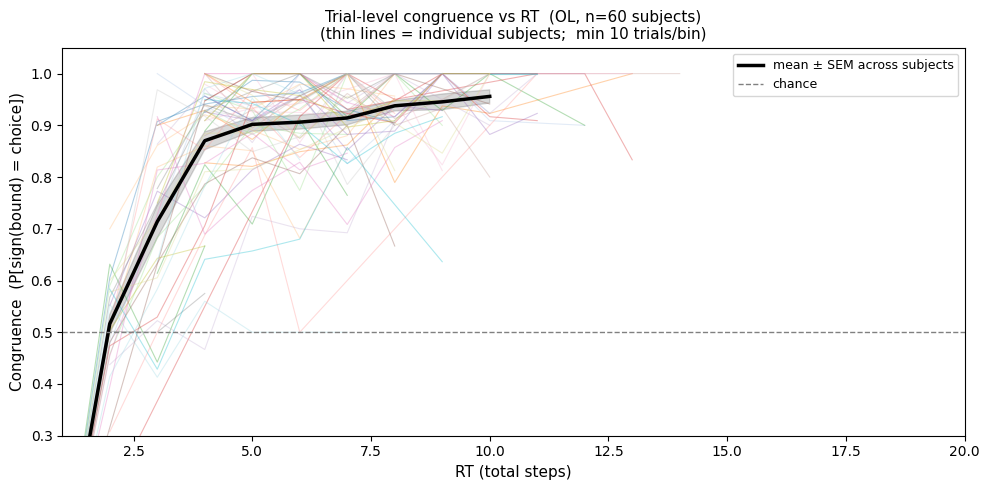

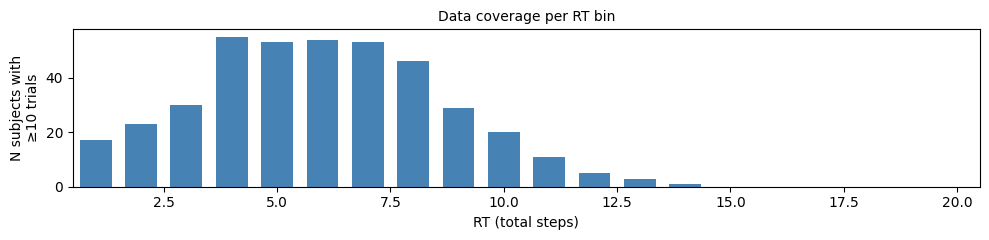

In [4]:
# ── Congruence vs RT: one line per subject, bold mean ───────────────────────
subjects  = sorted(df.subject_index.unique())
n_subj    = len(subjects)
rt_bins   = np.arange(1, df.RT.max() + 1)   # integer RT values

# Build per-subject congruence profile
cong_matrix = np.full((n_subj, len(rt_bins)), np.nan)
n_matrix    = np.zeros((n_subj, len(rt_bins)), dtype=int)

for si, subj in enumerate(subjects):
    sub = df[df.subject_index == subj]
    for ri, rt in enumerate(rt_bins):
        rows = sub[sub.RT == rt]
        valid = rows.congruent.dropna()
        n_matrix[si, ri] = len(valid)
        if len(valid) >= MIN_TRIALS_PER_BIN:
            cong_matrix[si, ri] = valid.mean()

# Mean and SEM across subjects (only using bins with enough data)
mean_cong = np.nanmean(cong_matrix, axis=0)
sem_cong  = stats.sem(cong_matrix, axis=0, nan_policy='omit')
n_subj_per_rt = np.sum(np.isfinite(cong_matrix), axis=0)

# ── Figure 1: raw subject lines ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.tab20
for si, subj in enumerate(subjects):
    valid_rt = rt_bins[np.isfinite(cong_matrix[si])]
    valid_cg = cong_matrix[si, np.isfinite(cong_matrix[si])]
    if len(valid_rt) > 0:
        ax.plot(valid_rt, valid_cg, '-', color=cmap(si / n_subj),
                alpha=0.35, linewidth=0.8)

# Bold mean ± SEM
valid_mean = n_subj_per_rt >= max(3, n_subj // 4)
ax.fill_between(rt_bins[valid_mean],
                mean_cong[valid_mean] - sem_cong[valid_mean],
                mean_cong[valid_mean] + sem_cong[valid_mean],
                color='k', alpha=0.15)
ax.plot(rt_bins[valid_mean], mean_cong[valid_mean], 'k-', linewidth=2.5,
        label='mean ± SEM across subjects')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
ax.set_xlabel('RT (total steps)', fontsize=11)
ax.set_ylabel('Congruence  (P[sign(bound) = choice])', fontsize=11)
ax.set_title(f'Trial-level congruence vs RT  ({TASK_TYPE}, n={n_subj} subjects)\n'
             f'(thin lines = individual subjects;  min {MIN_TRIALS_PER_BIN} trials/bin)',
             fontsize=11)
ax.set_xlim(1, min(20, rt_bins.max()))
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Figure 2: number of subjects with data per RT bin ───────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 2.5))
ax2.bar(rt_bins[:20], n_subj_per_rt[:20], color='steelblue', width=0.7)
ax2.set_xlabel('RT (total steps)', fontsize=10)
ax2.set_ylabel('N subjects with\n≥10 trials', fontsize=10)
ax2.set_title('Data coverage per RT bin', fontsize=10)
ax2.set_xlim(0.5, 20.5)
plt.tight_layout()
plt.show()

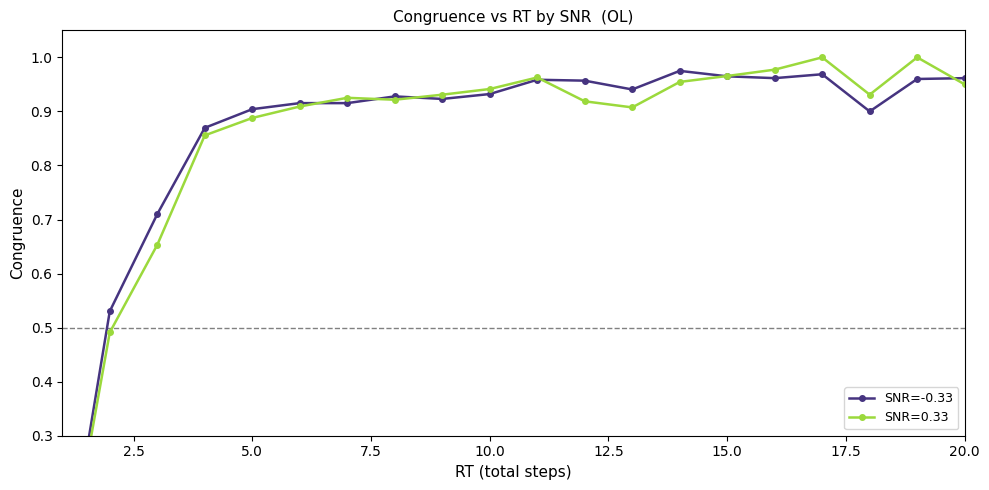

In [5]:
# ── Congruence vs RT split by SNR ────────────────────────────────────────────
snr_vals   = sorted(df.snr.unique())
snr_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(snr_vals)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

for snr, color in zip(snr_vals, snr_colors):
    sub = df[df.snr == snr]
    cong_by_rt = []
    for rt in rt_bins:
        rows = sub[sub.RT == rt].congruent.dropna()
        cong_by_rt.append(rows.mean() if len(rows) >= MIN_TRIALS_PER_BIN else np.nan)
    cong_by_rt = np.array(cong_by_rt)
    valid = np.isfinite(cong_by_rt)
    ax.plot(rt_bins[valid], cong_by_rt[valid], 'o-', color=color,
            linewidth=1.8, markersize=4, label=f'SNR={snr:.2f}')

ax.set_xlabel('RT (total steps)', fontsize=11)
ax.set_ylabel('Congruence', fontsize=11)
ax.set_title(f'Congruence vs RT by SNR  ({TASK_TYPE})', fontsize=11)
ax.set_xlim(1, min(20, rt_bins.max()))
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

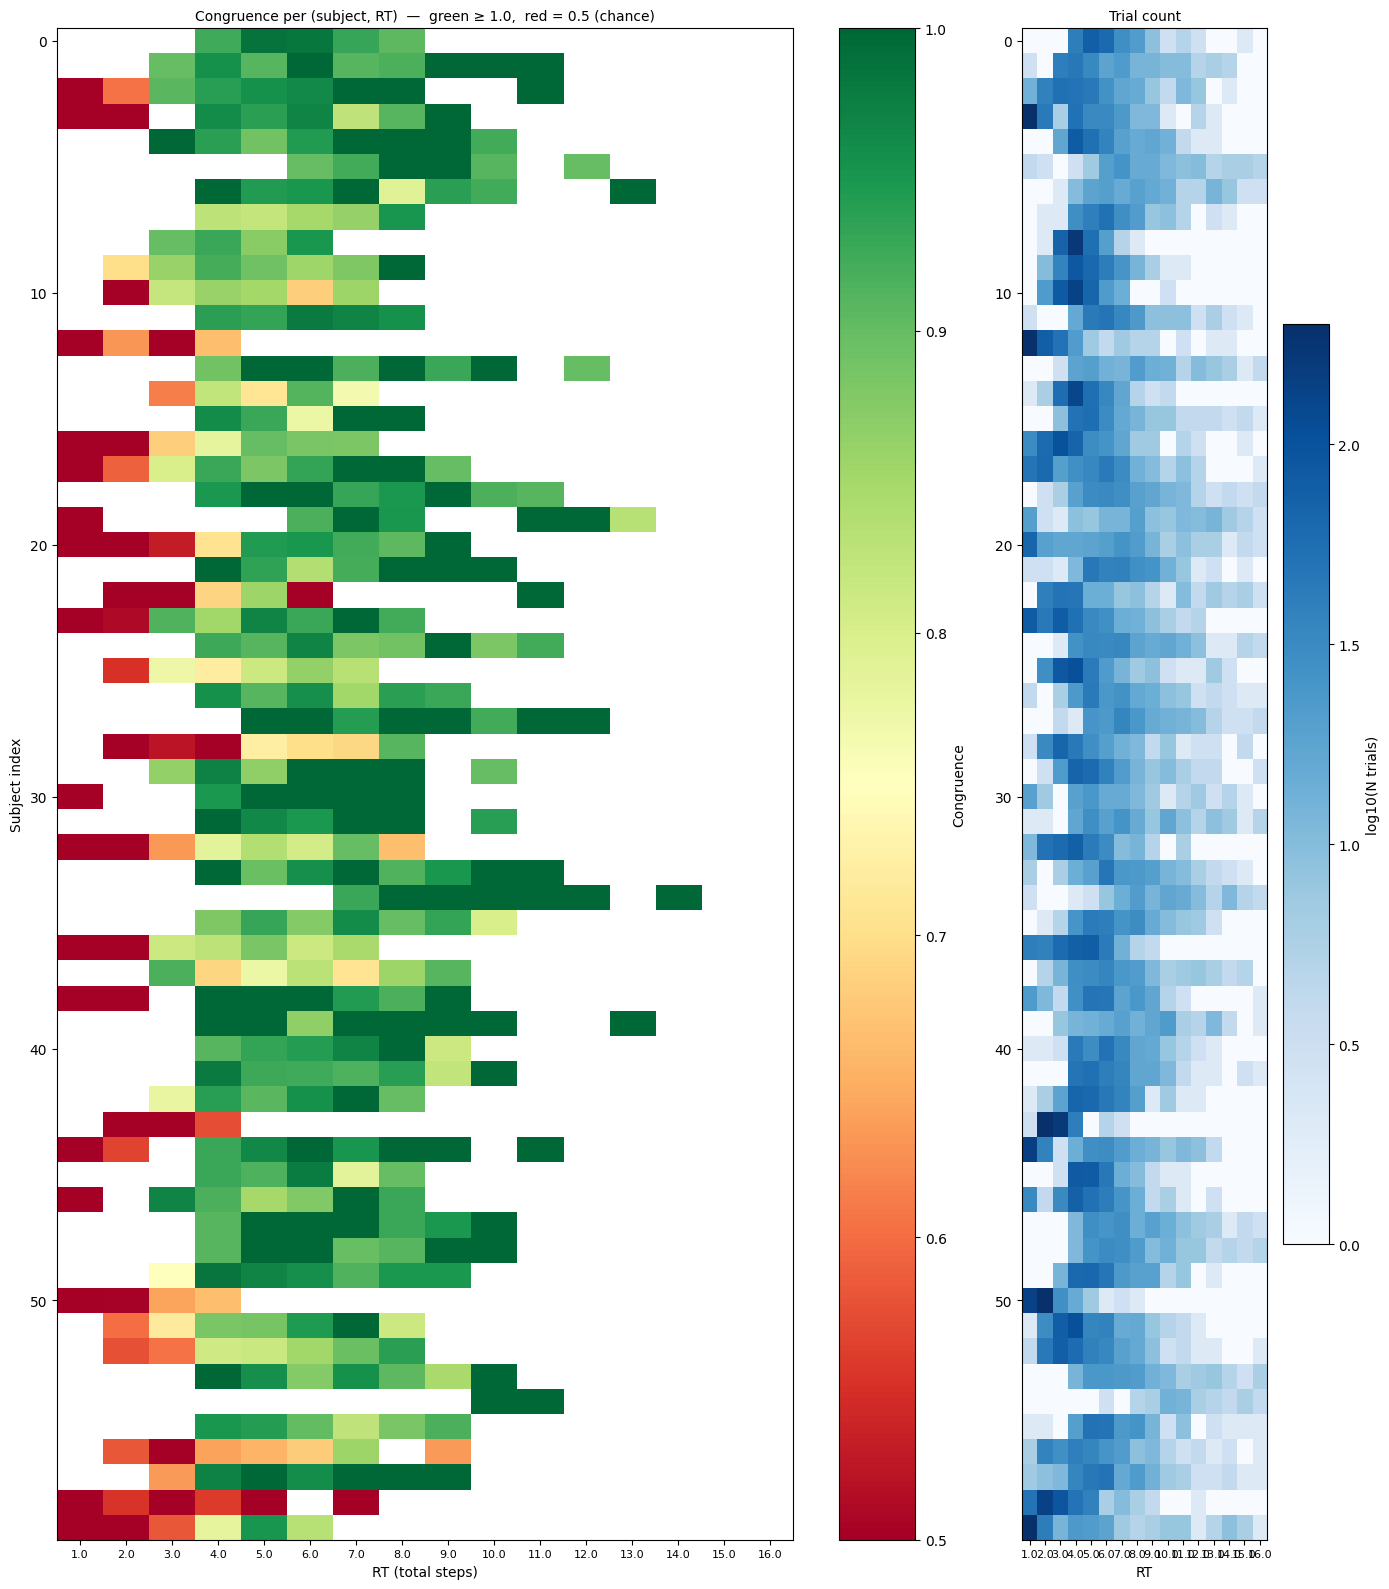

In [6]:
# ── Heatmap: congruence per (subject, RT bin) ────────────────────────────────
MAX_RT_SHOW = 16

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_subj * 0.25 + 1)),
                         gridspec_kw={'width_ratios': [3, 1]})

# Congruence heatmap
ax = axes[0]
im = ax.imshow(
    cong_matrix[:, :MAX_RT_SHOW],
    aspect='auto', origin='upper',
    vmin=0.5, vmax=1.0,
    cmap='RdYlGn',
    interpolation='nearest',
)
plt.colorbar(im, ax=ax, label='Congruence')
ax.set_xticks(np.arange(MAX_RT_SHOW))
ax.set_xticklabels(rt_bins[:MAX_RT_SHOW], fontsize=8)
ax.set_xlabel('RT (total steps)', fontsize=10)
ax.set_ylabel('Subject index', fontsize=10)
ax.set_title(f'Congruence per (subject, RT)  —  green ≥ 1.0,  red = 0.5 (chance)', fontsize=10)

# Trial count heatmap
ax2 = axes[1]
log_n = np.log10(np.maximum(n_matrix[:, :MAX_RT_SHOW], 0.5))
im2 = ax2.imshow(
    log_n,
    aspect='auto', origin='upper',
    vmin=0, vmax=np.log10(200),
    cmap='Blues',
    interpolation='nearest',
)
plt.colorbar(im2, ax=ax2, label='log10(N trials)')
ax2.set_xticks(np.arange(MAX_RT_SHOW))
ax2.set_xticklabels(rt_bins[:MAX_RT_SHOW], fontsize=8)
ax2.set_xlabel('RT', fontsize=10)
ax2.set_title('Trial count', fontsize=10)

plt.tight_layout()
plt.show()

RT  | mean cong | SEM   | N subj | p (vs 0.5) | sig
----+----------+-------+--------+------------+----
   1 | 0.000    | 0.000 |     17 | 0.0000     | ***
   2 | 0.516    | 0.018 |     23 | 0.3795     | 
   3 | 0.714    | 0.032 |     30 | 0.0000     | ***
   4 | 0.870    | 0.017 |     55 | 0.0000     | ***
   5 | 0.902    | 0.013 |     53 | 0.0000     | ***
   6 | 0.906    | 0.013 |     54 | 0.0000     | ***
   7 | 0.914    | 0.013 |     53 | 0.0000     | ***
   8 | 0.938    | 0.010 |     46 | 0.0000     | ***
   9 | 0.945    | 0.015 |     29 | 0.0000     | ***
  10 | 0.956    | 0.013 |     20 | 0.0000     | ***
  11 | 0.985    | 0.010 |     11 | 0.0000     | ***
  12 | 0.960    | 0.024 |      5 | 0.0000     | ***
  13 | 0.944    | 0.056 |      3 | 0.0153     | *


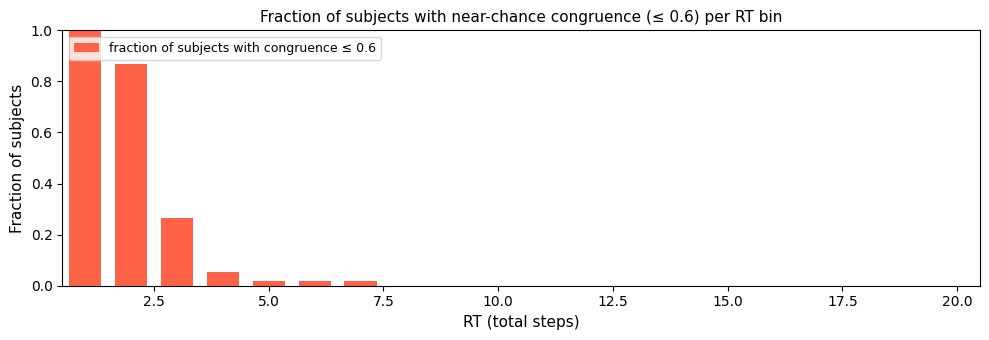

In [7]:
# ── Find RT threshold where congruence reliably exceeds chance ───────────────
# For each RT bin, test across subjects whether mean congruence > 0.5
# using a one-sample t-test. Report p-value and mean congruence.

print(f'RT  | mean cong | SEM   | N subj | p (vs 0.5) | sig')
print(f'----+----------+-------+--------+------------+----')

for ri, rt in enumerate(rt_bins[:20]):
    vals = cong_matrix[:, ri]
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3:
        continue
    t, p = stats.ttest_1samp(vals, 0.5)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {rt:2.0f} | {vals.mean():.3f}    | {stats.sem(vals):.3f} | {len(vals):6d} | {p:.4f}     | {sig}')

# ── Visual: fraction of subjects at chance per RT ────────────────────────────
CHANCE_THRESH = 0.6   # congruence ≤ this → probably guessing

frac_at_chance = np.array([
    np.mean(cong_matrix[:, ri][np.isfinite(cong_matrix[:, ri])] <= CHANCE_THRESH)
    if np.isfinite(cong_matrix[:, ri]).sum() >= 3 else np.nan
    for ri in range(len(rt_bins))
])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(rt_bins[:20], frac_at_chance[:20], color='tomato', width=0.7,
       label=f'fraction of subjects with congruence ≤ {CHANCE_THRESH}')
ax.set_xlabel('RT (total steps)', fontsize=11)
ax.set_ylabel('Fraction of subjects', fontsize=11)
ax.set_title(f'Fraction of subjects with near-chance congruence (≤ {CHANCE_THRESH}) per RT bin',
             fontsize=11)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()